In [ ]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn spacy gradio
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 40.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

import spacy

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import gradio as gr

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Saving imdb_movies.csv to imdb_movies (1).csv
Dataset loaded successfully!
Dataset shape: (10178, 12)


,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU
3,Mummies,01/05/2023,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU
4,Supercell,03/17/2023,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US


In [ ]:
print("Columns in dataset:")
for i, col in enumerate(df.columns):
    print(i, ":", repr(col))

Columns in dataset:
0 : 'names'
1 : 'date_x'
2 : 'score'
3 : 'genre'
4 : 'overview'
5 : 'crew'
6 : 'orig_title'
7 : 'status'
8 : 'orig_lang'
9 : 'budget_x'
10 : 'revenue'
11 : 'country'


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   names       10178 non-null  object 
 1   date_x      10178 non-null  object 
 2   score       10178 non-null  float64
 3   genre       10093 non-null  object 
 4   overview    10178 non-null  object 
 5   crew        10122 non-null  object 
 6   orig_title  10178 non-null  object 
 7   status      10178 non-null  object 
 8   orig_lang   10178 non-null  object 
 9   budget_x    10178 non-null  float64
 10  revenue     10178 non-null  float64
 11  country     10178 non-null  object 
dtypes: float64(3), object(9)
memory usage: 954.3+ KB
None


In [ ]:
df = pd.read_csv(filename)

column_mapping = {}

for col in df.columns:

    clean_col = (
        col.strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    if clean_col in ["overview", "summary", "description", "plot", "movie_summary"]:
        column_mapping[col] = "Overview"

    elif clean_col in ["genre", "genres"]:
        column_mapping[col] = "Genre"

    elif clean_col in ["crew", "cast_crew", "castandcrew"]:
        column_mapping[col] = "Crew"

    elif clean_col in ["budget_x", "movie_budget"]:
        column_mapping[col] = "Budget"

    elif clean_col in ["revenue", "movie_revenue"]:
        column_mapping[col] = "Revenue"

    elif clean_col in ["imdb_rating", "score", "rating", "imdb"]:
        column_mapping[col] = "IMDB_Rating"

    elif clean_col == "status":
        column_mapping[col] = "Status"

df = df.rename(columns=column_mapping)

print("Renamed columns:")
print(df.columns.tolist())

Renamed columns:
['names', 'date_x', 'IMDB_Rating', 'Genre', 'Overview', 'Crew', 'orig_title', 'Status', 'orig_lang', 'Budget', 'Revenue', 'country']


In [ ]:
required_columns = [
    "Overview",
    "Genre",
    "Crew",
    "Budget",
    "Revenue",
    "IMDB_Rating",
    "Status"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    print("❌ Missing columns:")
    print(missing_columns)
else:
    print("✅ All required columns are present!")

✅ All required columns are present!


In [ ]:
print(df.columns.tolist())

['names', 'date_x', 'IMDB_Rating', 'Genre', 'Overview', 'Crew', 'orig_title', 'Status', 'orig_lang', 'Budget', 'Revenue', 'country']


In [ ]:
df = df[required_columns].copy()

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (10178, 7)


,Overview,Genre,Crew,Budget,Revenue,IMDB_Rating,Status
0,"After dominating the boxing world, Adonis Cree...","Drama, Action","Michael B. Jordan, Adonis Creed, Tessa Thompso...",75000000.0,2.716167e+08,73.0,Released
1,Set more than a decade after the events of the...,"Science Fiction, Adventure, Action","Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",460000000.0,2.316795e+09,78.0,Released
2,"While working underground to fix a water main,...","Animation, Adventure, Family, Fantasy, Comedy","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",100000000.0,7.244590e+08,76.0,Released
3,"Through a series of unfortunate events, three ...","Animation, Comedy, Family, Adventure, Fantasy","Óscar Barberán, Thut (voice), Ana Esther Albor...",12300000.0,3.420000e+07,70.0,Released
4,Good-hearted teenager William always lived in ...,Action,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",77000000.0,3.409420e+08,61.0,Released


In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Overview        0
Genre          85
Crew           56
Budget          0
Revenue         0
IMDB_Rating     0
Status          0
dtype: int64


In [ ]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

print(missing_percentage)

Genre          0.835135
Crew           0.550206
Overview       0.000000
Budget         0.000000
Revenue        0.000000
IMDB_Rating    0.000000
Status         0.000000
dtype: float64


In [ ]:
df["Budget"] = pd.to_numeric(df["Budget"], errors="coerce")
df["Revenue"] = pd.to_numeric(df["Revenue"], errors="coerce")

print(df[["Budget", "Revenue"]].describe())

             Budget       Revenue
count  1.017800e+04  1.017800e+04
mean   6.488238e+07  2.531401e+08
std    5.707565e+07  2.777880e+08
min    1.000000e+00  0.000000e+00
25%    1.500000e+07  2.858898e+07
50%    5.000000e+07  1.529349e+08
75%    1.050000e+08  4.178021e+08
max    4.600000e+08  2.923706e+09


In [ ]:
df["IMDB_Rating"] = pd.to_numeric(
    df["IMDB_Rating"],
    errors="coerce"
)

print(df["IMDB_Rating"].describe())

count    10178.000000
mean        63.497052
std         13.537012
min          0.000000
25%         59.000000
50%         65.000000
75%         71.000000
max        100.000000
Name: IMDB_Rating, dtype: float64


In [ ]:
for col in ["Overview", "Genre", "Crew"]:

    df[col] = (
        df[col]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
    )

In [ ]:
print("Rows before cleaning:", len(df))

df = df[df["IMDB_Rating"] > 0].copy()

df["Status"] = df["Status"].astype(str).str.strip()
df = df[df["Status"] == "Released"].copy()

df = df[
    ~df["Overview"].str.contains("don't have an overview", case=False, regex=False)
].copy()

df = df.drop_duplicates().copy()

df["IMDB_Rating"] = df["IMDB_Rating"] / 10

print("Final dataset shape:", df.shape)
print(df["IMDB_Rating"].describe())

Rows before cleaning: 10178
Final dataset shape: (9912, 7)
count    9912.000000
mean        6.487470
std         0.994885
min         1.000000
25%         6.000000
50%         6.600000
75%         7.200000
max        10.000000
Name: IMDB_Rating, dtype: float64


In [ ]:
def rating_category(rating):

    if rating < 5:
        return "Poor"

    elif rating < 7:
        return "Average"

    elif rating < 8:
        return "Good"

    else:
        return "Excellent"

In [ ]:
df["Rating_Category"] = df["IMDB_Rating"].apply(
    rating_category
)

In [ ]:
print(df["Rating_Category"].value_counts())

Rating_Category
Average      6049
Good         2854
Poor          581
Excellent     428
Name: count, dtype: int64


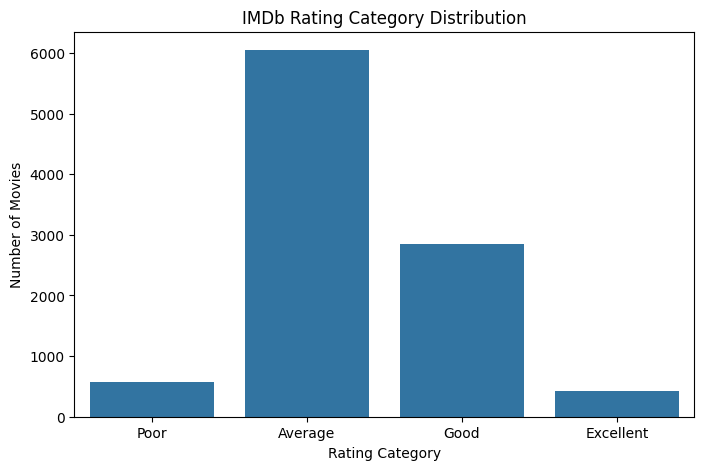

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Rating_Category",
    order=[
        "Poor",
        "Average",
        "Good",
        "Excellent"
    ]
)

plt.title("IMDb Rating Category Distribution")
plt.xlabel("Rating Category")
plt.ylabel("Number of Movies")
plt.show()

In [ ]:
def clean_text(text):

    text = str(text).lower()

    # Remove HTML
    text = re.sub(r"<.*?>", " ", text)

    # Keep letters, digits and spaces
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [ ]:
df["Clean_Overview"] = df["Overview"].apply(
    clean_text
)

In [ ]:
nlp = spacy.load("en_core_web_sm")

print("spaCy NER model loaded!")

spaCy NER model loaded!


In [ ]:
def extract_entities(text):

    doc = nlp(str(text))

    entities = []

    for ent in doc.ents:

        entities.append(
            f"{ent.text}_{ent.label_}"
        )

    return " ".join(entities)

In [ ]:
df["NER_Entities"] = df["Overview"].apply(
    extract_entities
)

In [ ]:
df[
    [
        "Overview",
        "NER_Entities"
    ]
].head(10)

,Overview,NER_Entities
0,"After dominating the boxing world, Adonis Cree...",Adonis Creed_PERSON Damien Anderson_PERSON Ado...
1,Set more than a decade after the events of the...,more than a decade_DATE first_ORDINAL Sully_PE...
2,"While working underground to fix a water main,...",Brooklyn_GPE Mario_PERSON Luigi_PERSON Mario_P...
3,"Through a series of unfortunate events, three ...",three_CARDINAL present-day_DATE London_GPE the...
4,Good-hearted teenager William always lived in ...,William_PERSON Zane Rogers_PERSON William_PERSON
5,"Inspired by a true story, an oddball group of ...",Georgia_GPE 500-pound_QUANTITY
6,"With the price on his head ever increasing, Jo...",John Wick_PERSON The High Table_WORK_OF_ART Wi...
7,Puss in Boots discovers that his passion for a...,eight_CARDINAL nine_CARDINAL only one_CARDINAL...
8,"As viable water is depleted on Earth, a missio...",Earth_LOC Saturn_PRODUCT Titan_GPE Titan_GPE E...
9,A dystopian coming-of-age movie focused on thr...,three_CARDINAL Neverland_FAC


In [ ]:
sample_text = df["Overview"].iloc[0]

doc = nlp(sample_text)

print("Movie Summary:")
print(sample_text)

print("\nDetected Entities:")

for ent in doc.ents:

    print(
        ent.text,
        "→",
        ent.label_
    )

Movie Summary:
After dominating the boxing world, Adonis Creed has been thriving in both his career and family life. When a childhood friend and former boxing prodigy, Damien Anderson, resurfaces after serving a long sentence in prison, he is eager to prove that he deserves his shot in the ring. The face-off between former friends is more than just a fight. To settle the score, Adonis must put his future on the line to battle Damien — a fighter who has nothing to lose.

Detected Entities:
Adonis Creed → PERSON
Damien Anderson → PERSON
Adonis → NORP
Damien → PERSON


In [ ]:
def bio_tagging(text):

    doc = nlp(str(text))

    bio_tokens = []

    entity_token_positions = set()

    for ent in doc.ents:

        for token in ent:

            entity_token_positions.add(token.i)

    for token in doc:

        if token.i not in entity_token_positions:

            bio_tokens.append(
                f"{token.text}/O"
            )

        else:

            ent = None

            for e in doc.ents:

                if token.i >= e.start and token.i < e.end:
                    ent = e
                    break

            if ent is not None:

                if token.i == ent.start:

                    bio_tokens.append(
                        f"{token.text}/B-{ent.label_}"
                    )

                else:

                    bio_tokens.append(
                        f"{token.text}/I-{ent.label_}"
                    )

    return " ".join(bio_tokens)

In [ ]:
df["BIO_Tags"] = df["Overview"].apply(
    bio_tagging
)

In [ ]:
print("Original Summary:")
print(df["Overview"].iloc[0])

print("\nBIO Tagged Summary:")
print(df["BIO_Tags"].iloc[0])

Original Summary:
After dominating the boxing world, Adonis Creed has been thriving in both his career and family life. When a childhood friend and former boxing prodigy, Damien Anderson, resurfaces after serving a long sentence in prison, he is eager to prove that he deserves his shot in the ring. The face-off between former friends is more than just a fight. To settle the score, Adonis must put his future on the line to battle Damien — a fighter who has nothing to lose.

BIO Tagged Summary:
After/O dominating/O the/O boxing/O world/O ,/O Adonis/B-PERSON Creed/I-PERSON has/O been/O thriving/O in/O both/O his/O career/O and/O family/O life/O ./O When/O a/O childhood/O friend/O and/O former/O boxing/O prodigy/O ,/O Damien/B-PERSON Anderson/I-PERSON ,/O resurfaces/O after/O serving/O a/O long/O sentence/O in/O prison/O ,/O he/O is/O eager/O to/O prove/O that/O he/O deserves/O his/O shot/O in/O the/O ring/O ./O The/O face/O -/O off/O between/O former/O friends/O is/O more/O than/O just/O 

In [ ]:
df["NLP_Features"] = (
    df["Clean_Overview"]
    + " "
    + df["NER_Entities"]
)

# Crew column alternates: actor, character, actor, character ...
# Keep only the first 5 actor names
def get_actors(crew):
    parts = [p.strip() for p in str(crew).split(",")]
    actors = parts[0::2][:5]
    return ", ".join(actors)

df["Actors"] = df["Crew"].apply(get_actors)

df[["Crew", "Actors"]].head()

,Crew,Actors
0,"Michael B. Jordan, Adonis Creed, Tessa Thompso...","Michael B. Jordan, Tessa Thompson, Jonathan Ma..."
1,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...","Sam Worthington, Zoe Saldaña, Sigourney Weaver..."
2,"Chris Pratt, Mario (voice), Anya Taylor-Joy, P...","Chris Pratt, Anya Taylor-Joy, Charlie Day, Jac..."
3,"Óscar Barberán, Thut (voice), Ana Esther Albor...","Óscar Barberán, Ana Esther Alborg, Luis Pérez ..."
4,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...","Skeet Ulrich, Anne Heche, Daniel Diemer, Jorda..."


In [ ]:
X = df[
    [
        "NLP_Features",
        "Genre",
        "Actors",
        "Budget"
    ]
]

y = df["Rating_Category"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 7929
Testing samples: 1983


In [ ]:
text_feature = "NLP_Features"

categorical_features = [
    "Genre",
    "Actors"
]

numeric_features = [
    "Budget"
]

In [ ]:
def split_on_comma(text):
    return [t.strip() for t in str(text).split(",") if t.strip()]


preprocessor = ColumnTransformer(

    transformers=[

        (
            "text",
            TfidfVectorizer(
                stop_words="english",
                max_features=8000,
                ngram_range=(1, 2),
                min_df=2
            ),
            text_feature
        ),

        (
            "genre",
            CountVectorizer(
                tokenizer=split_on_comma,
                token_pattern=None,
                lowercase=False,
                binary=True
            ),
            "Genre"
        ),

        (
            "actors",
            CountVectorizer(
                tokenizer=split_on_comma,
                token_pattern=None,
                lowercase=False,
                binary=True,
                min_df=5
            ),
            "Actors"
        ),

        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ]
)

In [ ]:
model = Pipeline([

    (
        "preprocessor",
        preprocessor
    ),

    (
        "classifier",

        LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )
    )
])

In [ ]:
print("Training Logistic Regression model...")

model.fit(
    X_train,
    y_train
)

print("✅ Model training completed!")

Training Logistic Regression model...
✅ Model training completed!


In [ ]:
predictions = model.predict(X_test)

print(predictions[:20])

['Average' 'Average' 'Average' 'Average' 'Average' 'Good' 'Average'
 'Average' 'Good' 'Good' 'Average' 'Good' 'Good' 'Good' 'Good' 'Average'
 'Average' 'Excellent' 'Average' 'Good']


In [ ]:
accuracy = accuracy_score(y_test, predictions)
macro_f1 = f1_score(y_test, predictions, average="macro")

# Baseline: always predicts the most common class
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_predictions = baseline.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_f1 = f1_score(y_test, baseline_predictions, average="macro")

print("Model Accuracy    :", round(accuracy * 100, 2), "%")
print("Model Macro F1    :", round(macro_f1, 4))
print()
print("Baseline Accuracy :", round(baseline_accuracy * 100, 2), "%")
print("Baseline Macro F1 :", round(baseline_f1, 4))

Model Accuracy    : 54.31 %
Model Macro F1    : 0.4002

Baseline Accuracy : 61.02 %
Baseline Macro F1 : 0.1895


In [ ]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

     Average       0.72      0.60      0.65      1210
   Excellent       0.18      0.24      0.21        86
        Good       0.44      0.51      0.47       571
        Poor       0.21      0.37      0.27       116

    accuracy                           0.54      1983
   macro avg       0.39      0.43      0.40      1983
weighted avg       0.59      0.54      0.56      1983



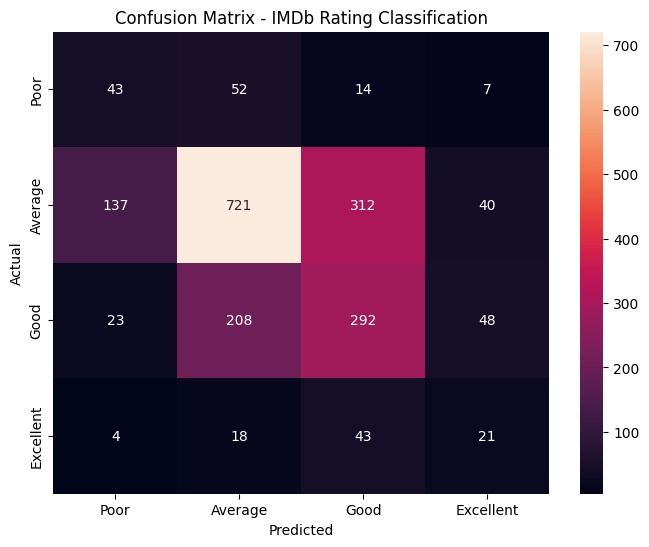

In [ ]:
labels = [
    "Poor",
    "Average",
    "Good",
    "Excellent"
]

cm = confusion_matrix(
    y_test,
    predictions,
    labels=labels
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - IMDb Rating Classification")

plt.show()

In [ ]:
results = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": predictions

})

results.head(20)

,Actual,Predicted
0,Poor,Average
1,Average,Average
2,Good,Average
3,Average,Average
4,Average,Average
5,Good,Good
6,Average,Average
7,Good,Average
8,Average,Good
9,Good,Good


In [ ]:
probabilities = model.predict_proba(X_test)

class_names = model.classes_

probability_df = pd.DataFrame(
    probabilities,
    columns=class_names
)

probability_df.head()

,Average,Excellent,Good,Poor
0,0.477773,0.005213,0.177427,0.339587
1,0.487664,0.007085,0.175371,0.329881
2,0.580489,0.001685,0.406397,0.011429
3,0.466913,0.094632,0.415272,0.023184
4,0.488792,0.047996,0.429683,0.033528


In [ ]:
from collections import Counter

entity_counter = Counter()

for text in df["Overview"]:

    doc = nlp(text)

    for ent in doc.ents:

        entity_counter[
            ent.label_
        ] += 1

entity_counts = pd.DataFrame(
    entity_counter.items(),
    columns=[
        "Entity Type",
        "Count"
    ]
).sort_values(
    "Count",
    ascending=False
)

entity_counts

,Entity Type,Count
0,PERSON,14634
4,ORG,5593
5,GPE,5020
2,DATE,3437
6,CARDINAL,2801
1,NORP,2100
10,LOC,910
3,ORDINAL,660
9,WORK_OF_ART,544
15,TIME,436


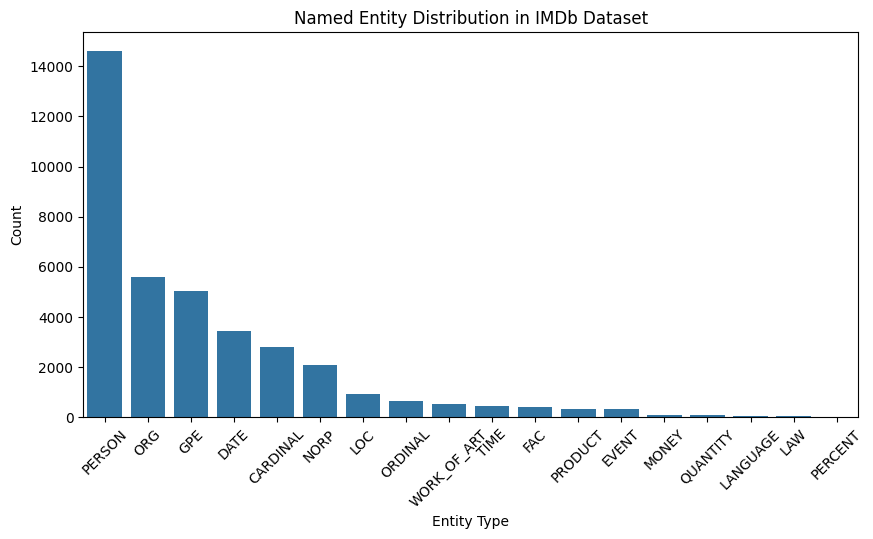

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=entity_counts,
    x="Entity Type",
    y="Count"
)

plt.xticks(rotation=45)

plt.title(
    "Named Entity Distribution in IMDb Dataset"
)

plt.show()

In [ ]:
tfidf = (
    model
    .named_steps[
        "preprocessor"
    ]
    .named_transformers_[
        "text"
    ]
)

feature_names = (
    tfidf
    .get_feature_names_out()
)

In [ ]:
classifier = (
    model
    .named_steps[
        "classifier"
    ]
)

In [ ]:
print(classifier.classes_)

['Average' 'Excellent' 'Good' 'Poor']


In [ ]:
classifier = model.named_steps["classifier"]
pre = model.named_steps["preprocessor"]

# Build feature names transformer by transformer (works on all sklearn versions)
feature_names_list = []

for name, transformer, columns in pre.transformers_:

    if name == "remainder" or transformer == "drop":
        continue

    try:
        names = transformer.get_feature_names_out()
    except Exception:
        names = columns if isinstance(columns, list) else [columns]

    feature_names_list.extend([f"{name}__{n}" for n in names])

all_feature_names = np.array(feature_names_list)

print("Classes:", classifier.classes_)
print("Coefficient shape:", classifier.coef_.shape)
print("Number of feature names:", len(all_feature_names))

for i, class_name in enumerate(classifier.classes_):

    # Binary model has only 1 row of coefficients
    if classifier.coef_.shape[0] == 1:
        coefficients = classifier.coef_[0] if i == 1 else -classifier.coef_[0]
    else:
        coefficients = classifier.coef_[i]

    top_indices = np.argsort(coefficients)[-15:][::-1]

    print("\n==============================")
    print("Rating Category:", class_name)
    print("==============================")

    for index in top_indices:
        print(
            all_feature_names[index],
            "→",
            round(coefficients[index], 4)
        )

Classes: ['Average' 'Excellent' 'Good' 'Poor']
Coefficient shape: (4, 9642)
Number of feature names: 9642

Rating Category: Average
text__dream → 1.113
text__king → 1.102
actors__Kristen Stewart → 1.091
actors__Ryan Phillippe → 1.0129
actors__Diane Lane → 0.9899
text__just → 0.9711
actors__Rikiya Koyama → 0.9575
actors__Demi Moore → 0.942
actors__Eddie Murphy → 0.939
actors__Chris Rock → 0.9361
actors__John Ortiz → 0.935
actors__Judy Greer → 0.9282
actors__Seann William Scott → 0.9238
actors__Steve Zahn → 0.9168
text__save → 0.9166

Rating Category: Excellent
actors__Charlie Chaplin → 2.85
actors__James Stewart → 2.023
text__dog → 1.7837
text__miserable → 1.6636
text__film → 1.6556
actors__Ha Jung-woo → 1.6019
genre__Unknown → 1.5985
actors__Dee Bradley Baker → 1.5789
actors__Song Kang-ho → 1.5771
actors__Martin Balsam → 1.5628
text__spirits → 1.5625
text__daughters → 1.5607
actors__Jack Nicholson → 1.5399
text__stage → 1.5361
actors__Takashi Shimura → 1.5106

Rating Category: Good
tex

In [ ]:
audit = X_test.copy()

audit["Actual"] = y_test.values

audit["Predicted"] = predictions

# Word count of the ORIGINAL summary (not the NLP_Features column)
audit["Summary_Length"] = (
    df.loc[X_test.index, "Overview"]
    .str.split()
    .str.len()
    .values
)

In [ ]:
audit["Summary_Group"] = np.where(

    audit["Summary_Length"] < 50,

    "Short Summary",

    "Long Summary"
)

In [ ]:
audit_results = []

for group in audit[
    "Summary_Group"
].unique():

    group_data = audit[
        audit["Summary_Group"] == group
    ]

    group_accuracy = accuracy_score(
        group_data["Actual"],
        group_data["Predicted"]
    )

    audit_results.append({

        "Group": group,

        "Movies": len(group_data),

        "Accuracy": group_accuracy

    })

audit_df = pd.DataFrame(
    audit_results
)

audit_df

,Group,Movies,Accuracy
0,Short Summary,1138,0.539543
1,Long Summary,845,0.547929


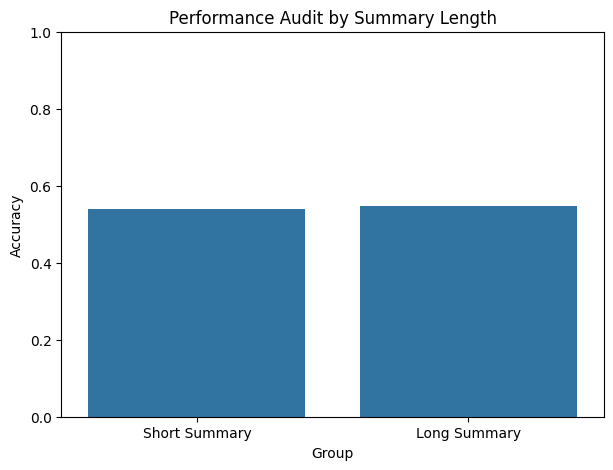

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=audit_df,
    x="Group",
    y="Accuracy"
)

plt.ylim(0,1)

plt.title(
    "Performance Audit by Summary Length"
)

plt.ylabel("Accuracy")

plt.show()

In [ ]:
audit["Main_Genre"] = (
    audit["Genre"]
    .str.split(",")
    .str[0]
    .str.strip()
)

In [ ]:
genre_counts = (
    audit["Main_Genre"]
    .value_counts()
)

print(genre_counts)

Main_Genre
Drama              368
Action             319
Comedy             274
Horror             179
Animation          156
Thriller           123
Adventure          106
Crime               86
Romance             78
Family              68
Science Fiction     60
Fantasy             50
Mystery             30
Documentary         26
Music               15
Western             12
War                 10
TV Movie             9
History              8
Unknown              6
Name: count, dtype: int64


In [ ]:
valid_genres = genre_counts[
    genre_counts >= 5
].index

In [ ]:
genre_results = []

for genre in valid_genres:

    group = audit[
        audit["Main_Genre"] == genre
    ]

    acc = accuracy_score(
        group["Actual"],
        group["Predicted"]
    )

    genre_results.append({

        "Genre": genre,

        "Movies": len(group),

        "Accuracy": acc

    })

genre_audit_df = pd.DataFrame(
    genre_results
).sort_values(
    "Accuracy"
)

genre_audit_df

,Genre,Movies,Accuracy
14,Music,15,0.266667
17,TV Movie,9,0.333333
19,Unknown,6,0.333333
16,War,10,0.400000
7,Crime,86,0.430233
0,Drama,368,0.442935
8,Romance,78,0.474359
4,Animation,156,0.493590
18,History,8,0.500000
15,Western,12,0.500000


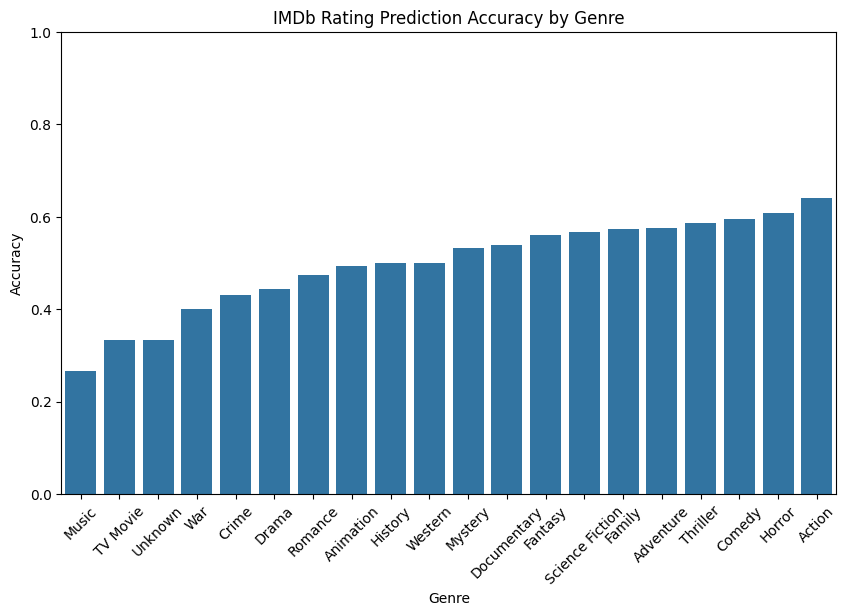

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=genre_audit_df,
    x="Genre",
    y="Accuracy"
)

plt.xticks(rotation=45)

plt.ylim(0,1)

plt.title(
    "IMDb Rating Prediction Accuracy by Genre"
)

plt.show()

In [ ]:
def predict_movie_rating(
    summary,
    genre,
    actors,
    budget
):

    # Clean summary
    clean_summary = clean_text(summary)

    # Extract NER entities
    ner_entities = extract_entities(summary)

    # Combine text + NER
    nlp_features = clean_summary + " " + ner_entities

    # Handle numeric input
    try:
        budget = float(budget)
    except (TypeError, ValueError):
        budget = df["Budget"].median()

    # Create input dataframe
    input_data = pd.DataFrame({
        "NLP_Features": [nlp_features],
        "Genre": [genre],
        "Actors": [actors],
        "Budget": [budget]
    })

    # Prediction
    prediction = model.predict(input_data)[0]

    # Probability
    probabilities = model.predict_proba(input_data)[0]
    class_names = model.classes_
    confidence = probabilities[list(class_names).index(prediction)] * 100

    # Category explanation
    if prediction == "Excellent":
        description = "The model predicts an excellent-rated movie (8.0 and above)."
    elif prediction == "Good":
        description = "The model predicts a good-rated movie (7.0 - 7.9)."
    elif prediction == "Average":
        description = "The model predicts an average-rated movie (5.0 - 6.9)."
    else:
        description = "The model predicts a poor-rated movie (below 5.0)."

    # Return values
    return (
        prediction,
        round(float(confidence), 2),
        ner_entities,
        description
    )

In [ ]:
demo = gr.Interface(

    fn=predict_movie_rating,

    inputs=[

        gr.Textbox(
            lines=7,
            label="🎬 Movie Summary",
            placeholder="Enter the movie plot or summary..."
        ),

        gr.Textbox(
            label="🎭 Genre",
            placeholder="Action, Adventure, Science Fiction"
        ),

        gr.Textbox(
            label="👥 Lead Actors (comma-separated)",
            placeholder="Tom Hanks, Meryl Streep"
        ),

        gr.Number(
            label="💰 Budget (USD)",
            value=50000000
        )
    ],

    outputs=[

        gr.Textbox(label="⭐ Predicted Rating Category"),

        gr.Number(label="📊 Model Confidence (%)"),

        gr.Textbox(label="🔍 Detected NER Entities"),

        gr.Textbox(label="📝 Explanation")
    ],

    title="🎬 IMDb Movie Rating Predictor",

    description=(
        "NLP-based IMDb rating classification "
        "using spaCy NER, TF-IDF and "
        "Logistic Regression."
    )
)

In [ ]:
demo.launch(
    share=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c5df01830237be4137.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
